In [30]:
import numpy as np
from regpy.operators.convolution import ConvolutionOperator, GaussianBlur, ExponentialConvolution
from regpy.vecsps import UniformGridFcts
from regpy.solvers import TikhonovRegularizationSetting, RegularizationSetting, RegSolver
from regpy.solvers.linear.semismoothNewton import SemismoothNewton_bilateral, SemismoothNewton_nonneg, SemismoothNewtonAlphaGrid
from regpy.solvers.linear.tikhonov import TikhonovCG
from regpy.solvers.linear.primal_dual import PDHG
from regpy.solvers.nonlinear.fista import FISTA
import regpy.functionals as fct
from regpy.hilbert import L2
from regpy.stoprules import CountIterations
from comparison_plot import comparison_plot
import logging

# Generate a test image as exact solution

In [31]:
grid = UniformGridFcts((-1, 1, 256), (-1.5, 1, 256),dtype = float, periodic = True)
"""Space of real-valued functions on a uniform grid with rectangular pixels"""
X = grid.coords[0]; Y = grid.coords[1]
"""x and y coordinates."""
cross = 1.0*np.logical_or((abs(X)<0.01) * (abs(Y)<0.3),(abs(X)<0.3) * (abs(Y)<0.01)) 
rad = np.sqrt(X**2 + Y**2)
ring = 1.0*np.logical_and(rad>=0.9, rad<=0.925)
smallbox = (abs(X+0.55)<=0.05) * (abs(Y-0.55)<=0.05)
bubbles = (1.001+np.sin(50/(X+1.3)))*np.exp(-((Y+1.25)/0.1)**2)*(X>-0.8)*(X<0.8)

ramp = Y<=-1

objects = 50*(ring + 2.0*cross + 1.5*smallbox + 2*ramp -bubbles)
exact_sol = objects 


# Generate synthetic data with impulsive noise

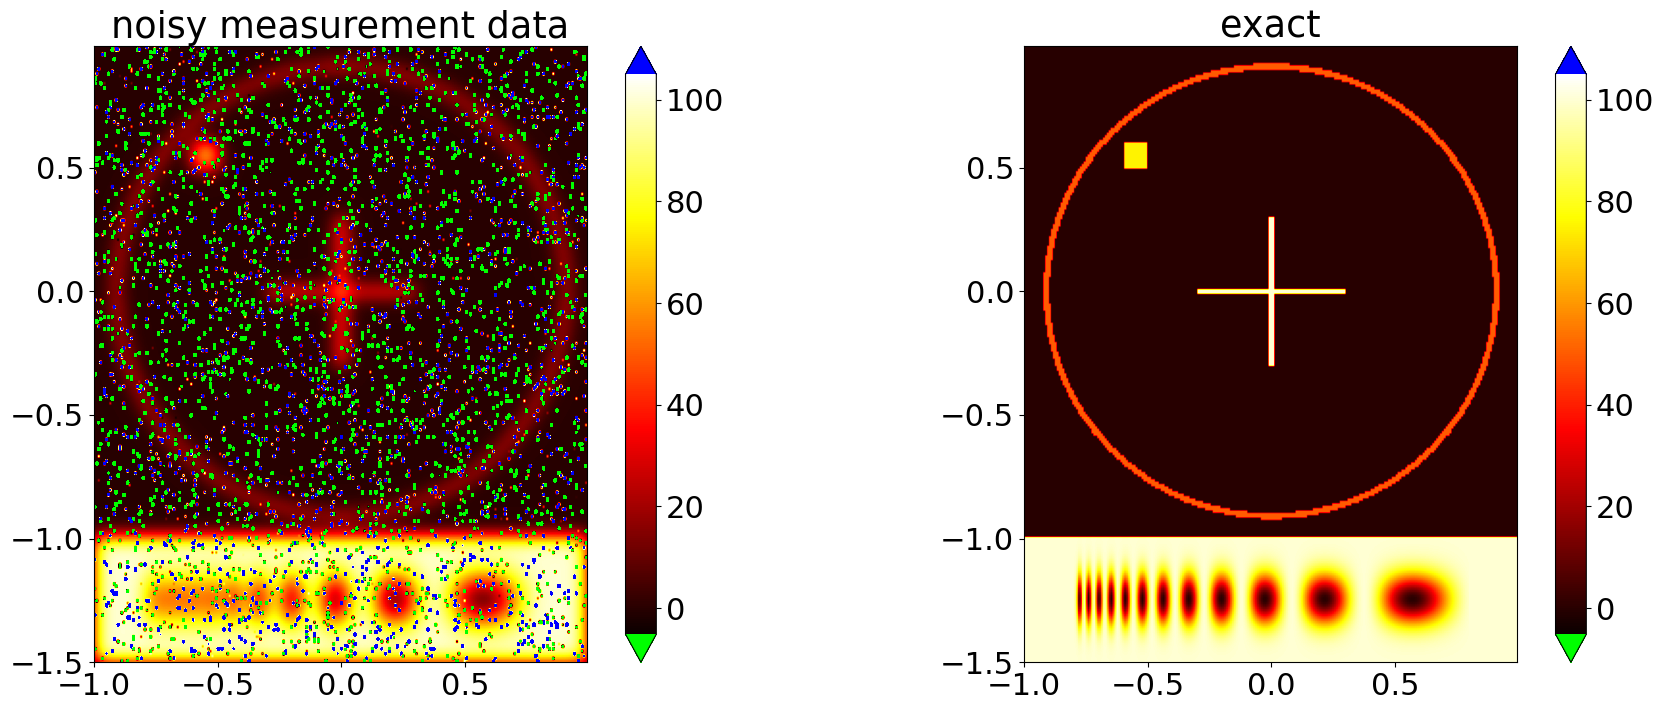

In [32]:
a=0.05
conv =  GaussianBlur(grid,a,pad_amount=((16,16),(16,16)))
"""Convolution operator \(f\mapsto h*f\) for the convolution kernel \(h(x)=\exp(-|x|_2^2/a^2)\)."""
blur = conv(exact_sol)
blur[blur<0] = 0.
data = blur.copy()
n,m=grid.shape
for j in range(64**2):
    nn = np.random.randint(n)
    mm = np.random.randint(m)
    data[nn,mm] =  np.random.randint(2000)-1000

comparison_plot(grid,exact_sol,data,title_left='noisy measurement data')

# Reconstruction with a quadratic data fidelity term

2024-06-29 10:53:58,533 INFO TikhonovCG           :: it.76 kappa=2.8176133108278156 err/Tol rel X:9.3e-07/1.0e-06 
2024-06-29 10:53:58,534 INFO TikhonovCG           :: Solver converged after 76 iteration.


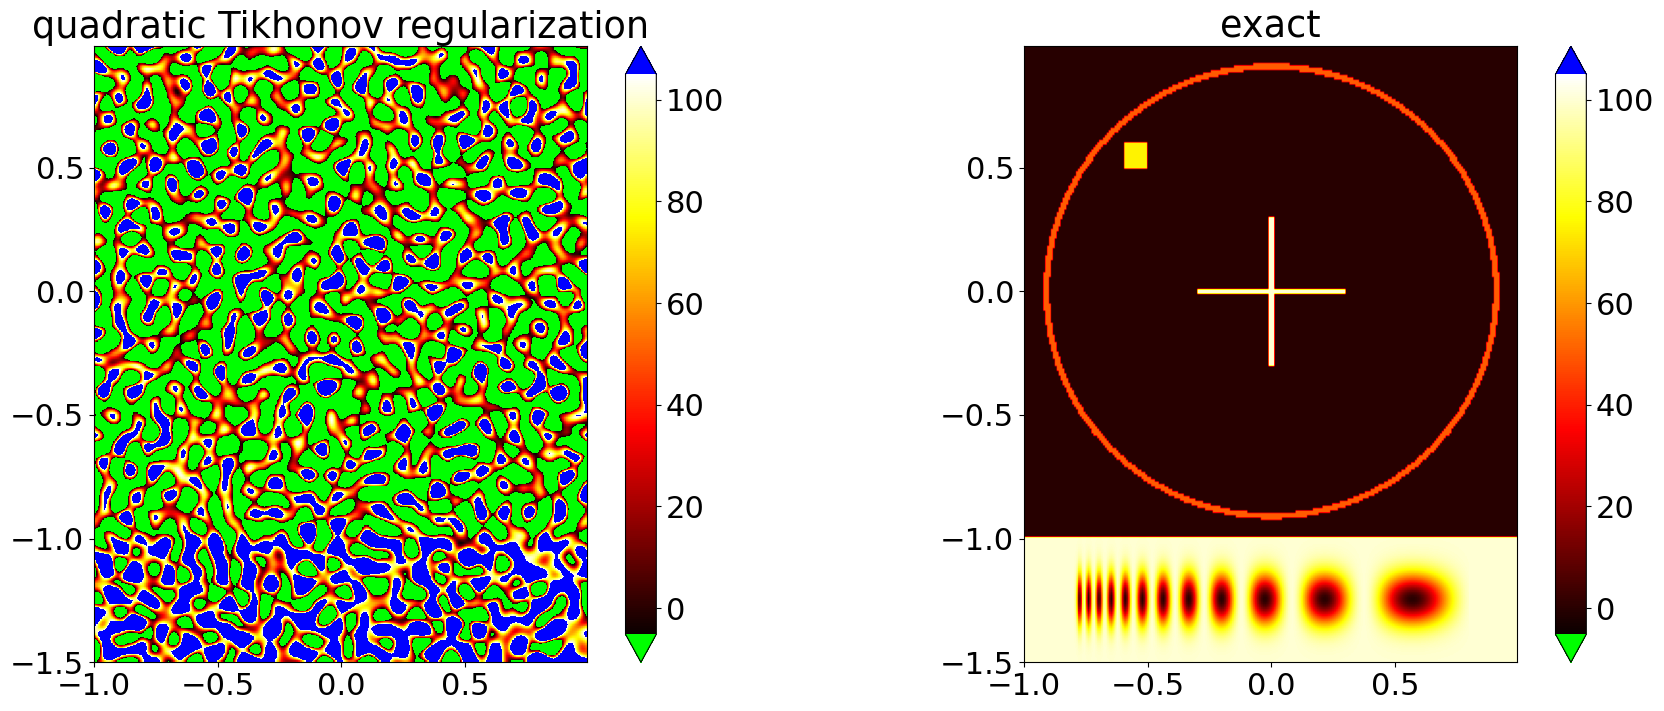

In [33]:
sigma = 10.
alpha = 0.01
setting = RegularizationSetting(conv,L2,L2)
solver = TikhonovCG(setting=setting, data = data, regpar = alpha,reltolx=1e-6)
fal,_ = solver.run()

comparison_plot(grid,exact_sol,fal,title_left='quadratic Tikhonov regularization')

# setting with Huber data fidelity term
We now set up a generalized Tikhonov regularization setting
$$
\hat{f} \in \mathrm{argmin}_f\left[\frac{1}{\alpha}H_{\sigma}(Tf-g^{\mathrm{obs}})+\|f\|^2\right]    
$$
where the Huber data fidelity term $H_{\sigma}$ is quadratic on coordinates in $[-\sigma,\sigma]$ and $|\cdot|-\sigma/2$ for large coordinates.

Moreover, we set up three solvers for this setting:
- FISTA
- Primal-Dual Hybrid Gradient (Chambolle-Pock) method
- Semismooth Newton method


In [34]:
Sdat = (1./sigma)*fct.Huber(grid,sigma=sigma)
Rfun = fct.QuadraticNonneg(grid)
huber_setting = TikhonovRegularizationSetting(conv,Rfun,Sdat,alpha,data_fid_shift=data)
dual_setting = huber_setting.dualSetting()

solverFISTA = FISTA(dual_setting,logging_level=logging.DEBUG)
solverPDHG = PDHG(huber_setting,logging_level=logging.DEBUG)
itPDHG = iter(solverPDHG)
itFISTA = iter(solverFISTA)

2024-06-29 10:54:00,437 INFO FISTA                :: Set up FISTA with convexity parameters mu_R=1.000e-01, mu_S=0.000e+00 and step length tau=1.005e+00.
 Expected linear convergence rate: 6.978e-01
2024-06-29 10:54:00,473 INFO FISTA                :: initial duality gap: 228.01172670957868
2024-06-29 10:54:01,235 INFO PDHG                 :: Using accelerated version 2 with convexity parameters mu_R=1.000e+00, mu_S*=1.000e-01 and ||T||=9.972e-01.
 Expected linear convergence rate: 6.119e-01


# FISTA
Run this cell until the duality gap is sufficiently small. 

2024-06-29 10:54:26,699 DEBUG FISTA                :: it.21: duality gap=2.044e-06


2024-06-29 10:54:26,766 DEBUG FISTA                :: it.22: duality gap=1.048e-06
2024-06-29 10:54:26,831 DEBUG FISTA                :: it.23: duality gap=5.443e-07
2024-06-29 10:54:26,883 DEBUG FISTA                :: it.24: duality gap=2.817e-07
2024-06-29 10:54:26,935 DEBUG FISTA                :: it.25: duality gap=1.471e-07
2024-06-29 10:54:26,983 DEBUG FISTA                :: it.26: duality gap=7.698e-08
2024-06-29 10:54:27,033 DEBUG FISTA                :: it.27: duality gap=3.998e-08
2024-06-29 10:54:27,080 DEBUG FISTA                :: it.28: duality gap=2.074e-08
2024-06-29 10:54:27,127 DEBUG FISTA                :: it.29: duality gap=1.071e-08
2024-06-29 10:54:27,169 DEBUG FISTA                :: it.30: duality gap=5.457e-09
2024-06-29 10:54:27,210 DEBUG FISTA                :: it.31: duality gap=2.765e-09
2024-06-29 10:54:27,258 DEBUG FISTA                :: it.32: duality gap=1.404e-09
2024-06-29 10:54:27,308 DEBUG FISTA                :: it.33: duality gap=7.096e-10
2024

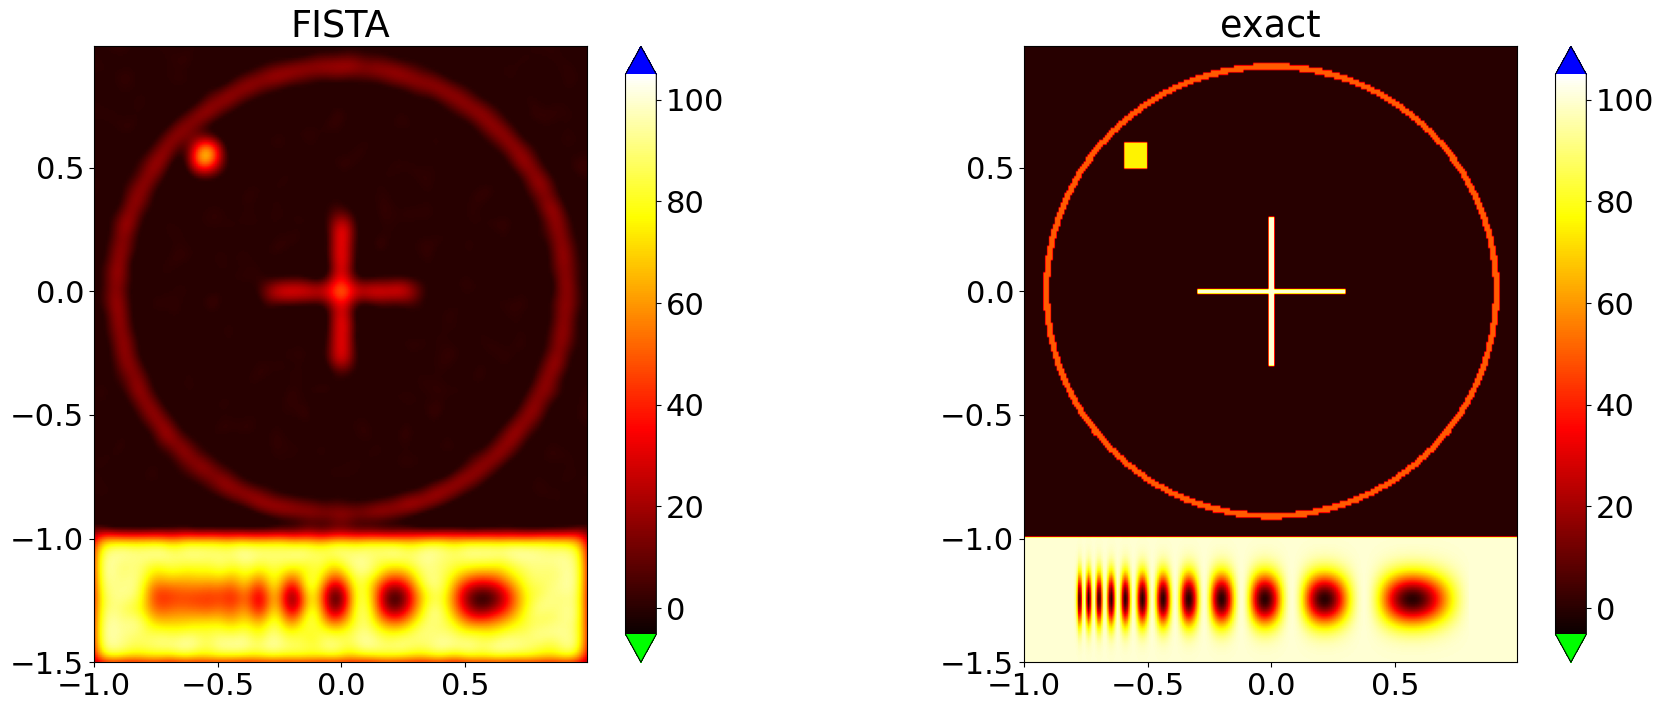

In [38]:
for j in range(20):
    p_FISTA,Tstar_pFISTA = next(itFISTA)
f_FISTA = huber_setting.dualToPrimal(Tstar_pFISTA,argumentIsOperatorImage=True)

comparison_plot(grid,exact_sol,f_FISTA,title_left='FISTA')

# PDHG
Run this cell until the duality gap is sufficiently small. 

2024-06-29 10:54:39,635 DEBUG PDHG                 :: it. 21: duality gap=2.335e-02
2024-06-29 10:54:39,718 DEBUG PDHG                 :: it. 22: duality gap=1.306e-02
2024-06-29 10:54:39,775 DEBUG PDHG                 :: it. 23: duality gap=7.074e-03
2024-06-29 10:54:39,826 DEBUG PDHG                 :: it. 24: duality gap=3.738e-03
2024-06-29 10:54:39,881 DEBUG PDHG                 :: it. 25: duality gap=1.953e-03
2024-06-29 10:54:39,935 DEBUG PDHG                 :: it. 26: duality gap=1.023e-03
2024-06-29 10:54:39,992 DEBUG PDHG                 :: it. 27: duality gap=5.436e-04
2024-06-29 10:54:40,055 DEBUG PDHG                 :: it. 28: duality gap=2.946e-04
2024-06-29 10:54:40,127 DEBUG PDHG                 :: it. 29: duality gap=1.626e-04
2024-06-29 10:54:40,192 DEBUG PDHG                 :: it. 30: duality gap=9.103e-05
2024-06-29 10:54:40,258 DEBUG PDHG                 :: it. 31: duality gap=5.144e-05
2024-06-29 10:54:40,317 DEBUG PDHG                 :: it. 32: duality gap=2.

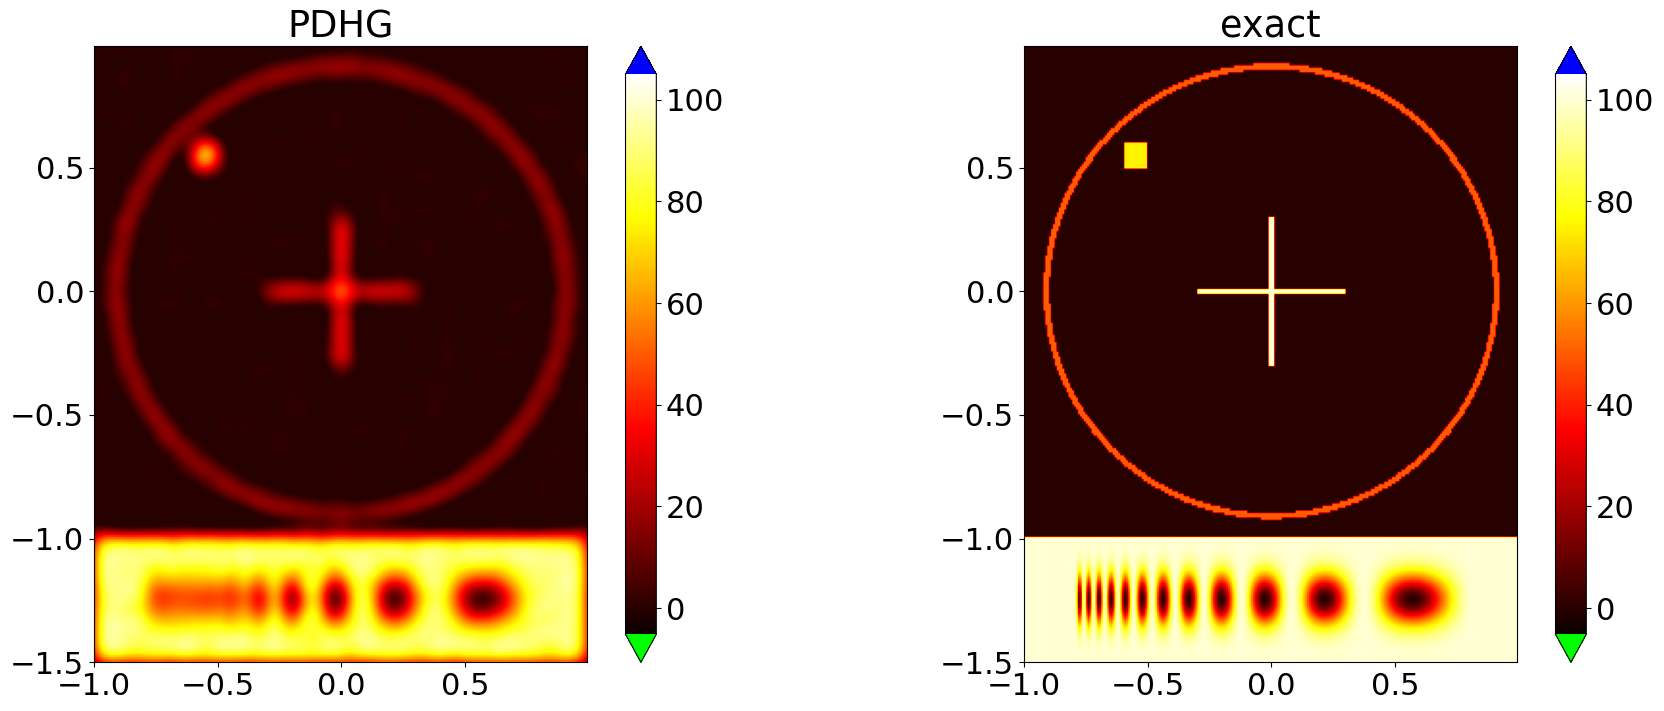

In [39]:
for j in range(20):
    f_PDHG,p_PDHG = next(itPDHG)

comparison_plot(grid,exact_sol,f_PDHG,title_left='PDHG')

# Semismooth Newton method

The method gives a solution that looks better than those of FISTA and PDHG, but the duality gap is much larger. 
(Possibly the effective regularization parameter is wrong!)

In [37]:
fig,((ax11,ax12,ax13),(ax21,ax22,ax23)) = plt.subplots(2,3)

ax11.plot(p_FISTA,label='p FISTA'); ax11.legend()
ax12.plot(solverPDHG.pstar,label='p PDHG');   ax12.legend()
ax13.plot(p_SS, label = 'p_SS');     ax13.legend()

ax21.plot(f_FISTA,label='f FISTA'); ax21.legend()
ax22.plot(f_PDHG,label='f PDHG');   ax22.legend()
ax23.plot(f_SS, label = 'f_SS');     ax23.legend()

NameError: name 'plt' is not defined